In [345]:
# from .. import HW1
# from HW1 import TESS_GeometricModel
import numpy as np
from scipy.linalg import expm
# from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [346]:
#Define operators

#hat operator
def hat(v):
    v = np.asarray(v).reshape(3,) #Maybe remove this
    return np.array([
        [0, -v[2], v[1]],
        [v[2], 0, -v[0]],
        [-v[1], v[0], 0]
    ])

H = np.vstack([np.zeros((1,3)), np.eye(3)])

#Left Quaternion
def L(q):
    q = np.asarray(q).reshape(4,) # I don't want to have this
    q0 = q[0]
    qv = q[1:4]

    top = np.hstack([q0, -qv])
    bottom = np.hstack([
        qv.reshape(3,1),
        q0*np.eye(3) + hat(qv)
    ])

    return np.vstack([top, bottom])

#Attitude Jacobian
def G(q):
    return L(q) @ H

In [347]:
#Load in old matrix
J_nom = np.diag([132.56, 101.64, 89.61]) #from HW1
evals, V = np.linalg.eigh(J_nom)

In [348]:
# 1 - Randomly preturn inertia matrix

def perturb_inertia(J_nom, sigma_eval=0.03, sigma_angle_deg=3.0):
    evals, V = np.linalg.eigh(J_nom)

    #perturb principal moments
    d = np.random.randn(3) * sigma_eval
    evals_tilde = evals * (1.0 + d)
    D_tilde = np.diag(evals_tilde)

    #perturb principal-axis
    sigma_angle = np.deg2rad(sigma_angle_deg)
    v = np.random.randn(3) * sigma_angle
    V_tilde = V @ expm(hat(v))

    # econstruct perturbed inertia
    J_tilde = V_tilde @ D_tilde @ V_tilde.T
    J_tilde = 0.5 * (J_tilde + J_tilde.T) #Is this necessary

    return J_tilde, evals_tilde, V_tilde

#Call function
J, evals, V = perturb_inertia(J_nom, sigma_eval=0.03, sigma_angle_deg=3.0)

print("Perturbed inertia matrix: ", J)


Perturbed inertia matrix:  [[ 1.27696613e+02  7.74047803e-02  3.00917801e+00]
 [ 7.74047803e-02  9.88623981e+01 -2.96921585e-01]
 [ 3.00917801e+00 -2.96921585e-01  8.80191763e+01]]


In [349]:
# 2 - Desired safe-mode spin
#Note: solar panel along +y axis in body frame
n_panel = np.array([0.0, 1.0, 0.0]) #panel normal in body frame
n_panel = n_panel / np.linalg.norm(n_panel)

rpm = 10.0 #rev / min
omega = rpm * 2*np.pi / 60.0 #rad / s
omega_s = omega * n_panel #desired spin angular velocity
print("Desired angular velocity: ", omega_s)

Desired angular velocity:  [0.         1.04719755 0.        ]


In [350]:
# 3 - Calculate rotor momentum using Superspin and dynamic balance 
inertia_ratio = 1.2
w_s = np.asarray(omega_s).reshape(3,)

s = w_s / np.linalg.norm(w_s)
Js = s.T @ J @ s #Scalar inertia about spin direction
J_max = np.max(evals) #Major inertia axis moment
rho_s = np.linalg.norm(w_s)*(inertia_ratio*J_max - Js) #Enforces superspin margin (parallel wheel momentum)

#Solve no-wobble and superspin conditions using linear least-squares
A = np.vstack([
    w_s.reshape(1, 3),
    hat(w_s)
])

b = np.hstack([
    rho_s * np.linalg.norm(w_s),
    -hat(w_s) @ (J @ w_s)
])

rho0, *_ = np.linalg.lstsq(A, b, rcond=None)

print("Rotor momentum: ", rho0)

#Delete later
# Optional diagnostic: check dynamic balance
h_total = J @ w_s + rho0
print("Total angular momentum J*omega_s + rho0 =", h_total)
print("Cross product omega_s x (J*omega_s + rho0) =", np.cross(w_s, h_total))

Rotor momentum:  [-0.0810581  57.2251239   0.31093556]
Total angular momentum J*omega_s + rho0 = [-1.24900090e-15  1.60753585e+02  4.44089210e-16]
Cross product omega_s x (J*omega_s + rho0) = [ 4.65049133e-16 -0.00000000e+00  1.30795069e-15]


In [351]:
# 4 - Add rotors to Euler equation code to implement gyrostat equation
def dynamics(t, x): #Why is there a t?
    q = x[0:4]
    q = q / np.linalg.norm(q)
    w = x[4:7]
    rho = x[7:10]

    rho_dot = np.zeros(3)
    q_dot = 0.5 * G(q) @ w
    w_dot = -np.linalg.solve(J, rho_dot + hat(w) @ (J @ w + rho)) #gyrostat equation

    return np.hstack([q_dot, w_dot, rho_dot])

In [352]:
#Runge-Kutta Solver
def rkstep(fun, t, x, dt):
    k1 = fun(t, x)
    k2 = fun(t + 0.5*dt, x + 0.5*dt * k1)
    k3 = fun(t + 0.5*dt, x + 0.5*dt * k2)
    k4 = fun(t + dt, x + dt * k3)

    return x + dt/6.0 * (k1 + 2*k2 + 2*k3 + k4)

In [353]:
#Initial conditions
h = 0.1 #time step
n = 600 #number of time steps
tf = n*h #final time

#sample random angular velocity
q0 = np.array([1.0, 0.0, 0.0, 0.0])
w0 = w_s + 0.03*np.random.randn(3) #Randomized perturbed angular velocity
# w0 = w_s + np.array([0.01, -0.01, 0.02]) #[What is this added part]
x0 = np.hstack([q0, w0, rho0])

In [354]:
#5 - Simulate stable spin configuration with RK4
t0 = 0
tf = 400
dt =0.1
t = np.arange(t0, tf + dt, dt)

xhist = np.zeros((len(t), 10))
xhist[0, :] = x0

for k in range(len(t)-1):
    xhist[k+1,:] = rkstep(dynamics, t[k], xhist[k,:], dt)

    q = xhist[k+1, 0:4]
    xhist[k+1, 0:4] = q / np.linalg.norm(q)

q_hist = xhist[:, 0:4]
w_hist = xhist[:, 4:7]
rho_hist = xhist[:, 7:10]

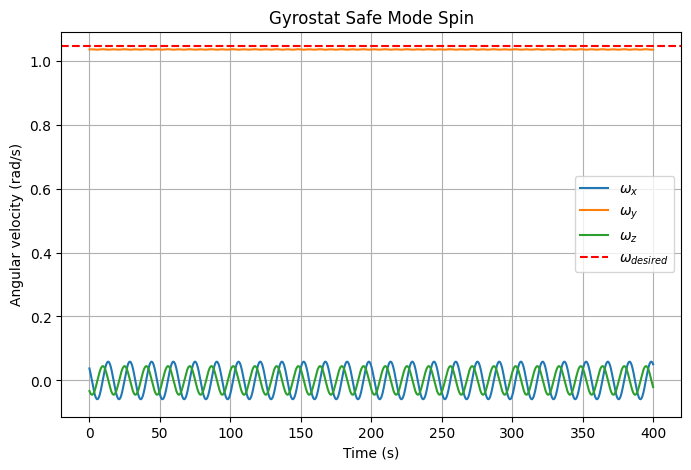

In [355]:
plt.figure(figsize=(8,5))

plt.plot(t, w_hist[:,0], label=r'$\omega_x$')
plt.plot(t, w_hist[:,1], label=r'$\omega_y$')
plt.plot(t, w_hist[:,2], label=r'$\omega_z$')

# plt.axhline(w_s[0],linestyle='--')
plt.axhline(w_s[1], linestyle='--', color='red', label=r'$\omega_{desired}$') #Only y-axis
# plt.axhline(w_s[2],linestyle='--')

plt.xlabel("Time (s)")
plt.ylabel("Angular velocity (rad/s)")
plt.title("Gyrostat Safe Mode Spin")

plt.legend()
plt.grid()

plt.show()

In [ ]:
#Values for Part 2
print(q0, w0, rho0)

[1. 0. 0. 0.] [ 0.03748229  1.03510176 -0.03310972] [-0.0810581  57.2251239   0.31093556]


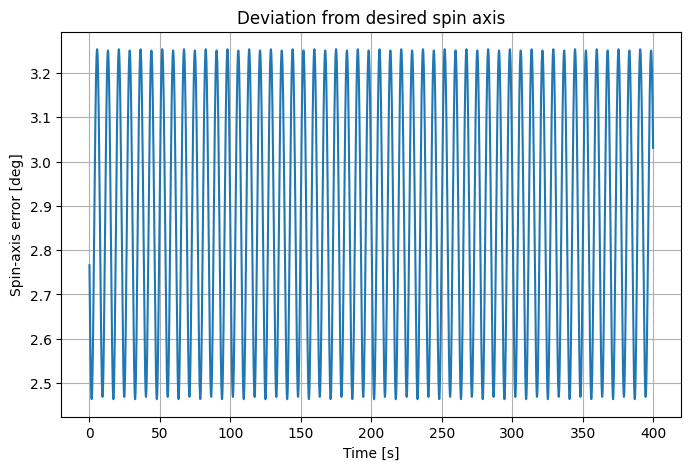

In [357]:
#Check the angle
s_des = w_s / np.linalg.norm(w_s)

s_hist = w_hist / np.linalg.norm(w_hist,axis=1,keepdims=True)

cosang = np.clip(s_hist @ s_des,-1,1)
angle_error = np.degrees(np.arccos(cosang))

plt.figure(figsize=(8,5))

plt.plot(t, angle_error)

plt.xlabel("Time [s]")
plt.ylabel("Spin-axis error [deg]")

plt.title("Deviation from desired spin axis")

plt.grid()

plt.show()